In [1]:
!pip install kagglehub xgboost scikit-learn pandas numpy matplotlib seaborn

In [2]:
import kagglehub
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Download latest version
path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")

print("Dataset path:", path)

100%|██████████| 751k/751k [00:00<00:00, 54.5MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/taweilo/loan-approval-classification-data/versions/1


In [4]:
import os

print(os.listdir(path))

['loan_data.csv']


In [7]:
file_path = os.path.join(path, 'loan_data.csv')
df = pd.read_csv(file_path)

print(df.shape)
print(df.info())
print(df.isnull().sum())

(45000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaul

In [8]:
df = df.dropna()

In [9]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [10]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [13]:
y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9297777777777778

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      6990
           1       0.89      0.78      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.92      0.88      0.89      9000
weighted avg       0.93      0.93      0.93      9000



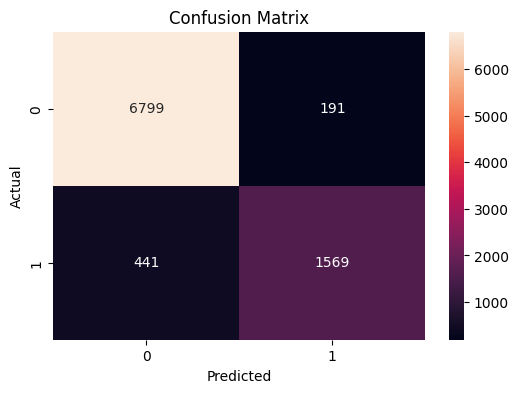

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

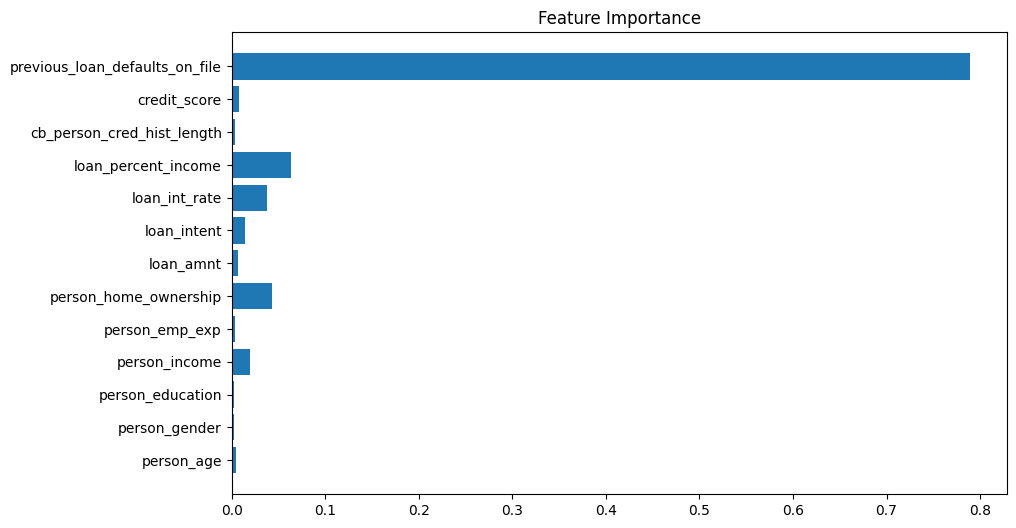

In [16]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [17]:
import joblib

joblib.dump(model, "loan_approval_model.pkl")

['loan_approval_model.pkl']

In [18]:
model = joblib.load("loan_approval_model.pkl")

In [19]:
!pip install kagglehub xgboost scikit-learn pandas numpy matplotlib seaborn joblib

In [20]:
import kagglehub
import os
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")

print("Dataset path:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'loan-approval-classification-data' dataset.
Dataset path: /kaggle/input/loan-approval-classification-data
['loan_data.csv']


In [22]:
df = pd.read_csv(os.path.join(path, "loan_data.csv"))

print(df.shape)
df.head()

(45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [23]:
# remove duplicates
df = df.drop_duplicates()

# remove missing values
df = df.dropna()

In [24]:
print(df.columns)

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')


In [25]:
target = "loan_status"

X = df.drop(target, axis=1)
y = df[target]

In [26]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

In [27]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [28]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=1,
    random_state=42,
    eval_metric="logloss"
)

In [29]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", model)
])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ign...
                               feature_types=None, feature_weights=None,
                               gamma=1, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [32]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

In [33]:
accuracy = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.937
ROC-AUC: 0.979501357142857

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7000
           1       0.90      0.80      0.85      2000

    accuracy                           0.94      9000
   macro avg       0.92      0.89      0.91      9000
weighted avg       0.94      0.94      0.94      9000



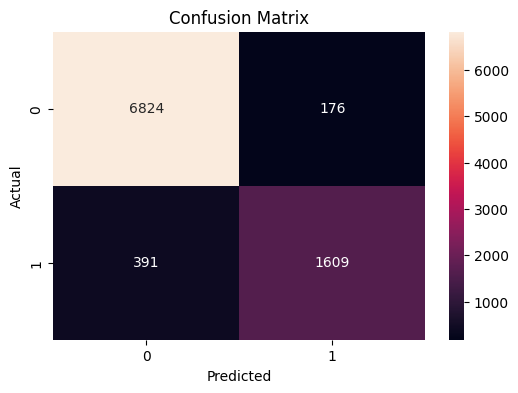

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
joblib.dump(pipeline, "loan_approval_xgboost_pipeline.pkl")

print("Model saved successfully")

Model saved successfully


In [36]:
model = joblib.load("loan_approval_xgboost_pipeline.pkl")

In [37]:
joblib.dump(pipeline, "loan_approval_xgboost_pipeline.pkl")

['loan_approval_xgboost_pipeline.pkl']

In [38]:
from google.colab import files
files.download("loan_approval_xgboost_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>